<a href="https://colab.research.google.com/github/DymaStar/DTA_2026/blob/main/ML/DS_150626_CW%2BHW_ml_practice_LR%26Cl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика: лінійна регресія та класифікація

Це тренувальний блокнот для закріплення базового циклу ML. Завдання **нескладні** й повторюють кроки з основного тьюторіалу — тільки тепер усе робиш **сам**.

**Дві задачі на двох нових наборах даних:**
- **Задача A (регресія):** передбачити **зарплату** працівника.
- **Задача B (класифікація):** передбачити, чи **складе студент іспит** (так/ні).

**Як працювати:**
1. Запусти комірку «Підготовка даних» нижче — вона все налаштує.
2. Іди по кроках. Там, де стоїть `# TODO`, — впиши свій код.
3. Підказки є під кожним кроком.

> 💡 Усі потрібні інструменти ти вже бачив: `train_test_split`, `LinearRegression`, `DecisionTreeClassifier`, `.fit()`, `.predict()`, метрики. Тримай той блокнот поруч як шпаргалку.

---

## 🔧 Підготовка даних (просто запусти)

In [ ]:
# ▶️ Просто запусти цю комірку — вона готує дані. Міняти нічого не треба.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

# ---------- Дані A: ЗАРПЛАТИ (для регресії) ----------
N = 800
experience = np.random.randint(0, 31, N)                      # стаж, років
age        = (22 + experience + np.random.randint(0, 12, N)).clip(22, 64)  # вік
education  = np.random.choice([12, 15, 16, 18, 20], N,        # років освіти
                              p=[.2, .15, .35, .2, .1])
english    = np.random.randint(1, 6, N)                       # рівень англ. 1..5

salary = (8000                       # базова ставка, грн
          + experience * 900         # за кожен рік стажу
          + education  * 600         # за рік освіти
          + english    * 1500        # за рівень англійської
          + np.random.normal(0, 3000, N)   # шум: усе інше
         ).clip(8000, None)

salary_df = pd.DataFrame({
    "experience": experience, "age": age,
    "education": education, "english": english,
    "salary": salary.round(0).astype(int),
})

# ---------- Дані B: СТУДЕНТИ (для класифікації) ----------
M = 800
study     = np.random.normal(12, 5, M).clip(0, 30)            # годин навчання/тиждень
attendance= np.random.normal(78, 15, M).clip(30, 100)        # відвідуваність, %
prev_score= np.random.normal(65, 18, M).clip(0, 100)         # бал за минулий іспит
sleep     = np.random.normal(7, 1.2, M).clip(4, 10)          # годин сну

score_logit = (0.12*study + 0.04*attendance + 0.05*prev_score
               + 0.3*sleep - 9 + np.random.normal(0, 1.2, M))
passed = (score_logit > 0).astype(int)                        # 1 = склав, 0 = ні

students_df = pd.DataFrame({
    "study": study.round(1), "attendance": attendance.round(0).astype(int),
    "prev_score": prev_score.round(0).astype(int), "sleep": sleep.round(1),
    "passed": passed,
})

print("✅ Дані готові.")
print("Зарплати:", salary_df.shape, "| Студенти:", students_df.shape)
print("Частка тих, хто склав іспит:", f"{students_df['passed'].mean():.0%}")

✅ Дані готові.
Зарплати: (800, 5) | Студенти: (800, 5)
Частка тих, хто склав іспит: 69%


---
# 🟦 Задача A. Регресія: передбачаємо зарплату

Дані у таблиці `salary_df`. Ознаки: `experience` (стаж), `age` (вік), `education` (років освіти), `english` (рівень англійської 1–5). Ціль: `salary` (зарплата, грн).

Мета — навчити модель передбачати зарплату і **пояснити**, що на неї впливає.

### Крок A1. Подивись на дані
Виведи перші рядки таблиці й описову статистику. Це звичка №1 перед будь-яким навчанням.

*Підказка:* `salary_df.head()` і `salary_df.describe()`.

In [ ]:
# TODO: виведи перші рядки salary_df
display(salary_df.head())
# TODO: виведи describe()
salary_df.describe()

,experience,age,education,english,salary
0,6,32,15,2,23714
1,19,44,12,3,32814
2,28,54,12,5,54472
3,14,42,20,5,35964
4,10,40,18,2,29723


,experience,age,education,english,salary
count,800.000000,800.000000,800.000000,800.000000,800.000000
mean,15.418750,42.746250,15.856250,3.028750,36028.926250
std,9.328568,9.924338,2.408908,1.432826,9242.043432
min,0.000000,22.000000,12.000000,1.000000,12917.000000
25%,7.000000,35.000000,15.000000,2.000000,28550.750000
50%,16.000000,43.000000,16.000000,3.000000,36102.500000
75%,24.000000,51.000000,18.000000,4.000000,43545.500000
max,30.000000,62.000000,20.000000,5.000000,55947.000000


### Крок A2. Признач ознаки (X) і ціль (y), поділи на train / test
- `X` — усі стовпці, КРІМ `salary`.
- `y` — стовпець `salary`.
- Поділ: 20% у тест, `random_state=RANDOM_STATE`.

*Підказка:* `X = salary_df[["experience", "age", "education", "english"]]`,
`y = salary_df["salary"]`, далі `train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)`.

In [ ]:
from sklearn.model_selection import train_test_split

# TODO: створи X та y
# X — це ознаки, на основі яких модель буде прогнозувати salary
# Беремо всі стовпці, які можуть впливати на зарплату:
# experience — стаж
# age — вік
# education — роки освіти
# english — рівень англійської
X = salary_df[["experience", "age", "education", "english"]]

# y — це цільова змінна, яку модель має передбачити
# У нашому випадку це зарплата
y = salary_df["salary"]

# TODO: поділи на X_train, X_test, y_train, y_test

# Ділимо дані на навчальну і тестову вибірки
# test_size=0.2 означає, що 20% даних підуть на тест
# random_state=RANDOM_STATE потрібен, щоб результат був однаковий при повторному запуску
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
# Перевіряємо, скільки рядків потрапило у train і test
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 640 | Test: 160


### Крок A3. Навчи лінійну регресію
Згадай цикл: **створити → `.fit(X_train, y_train)`**.

*Підказка:* `from sklearn.linear_model import LinearRegression`, далі `model = LinearRegression()` і `model.fit(...)`.

In [ ]:
from sklearn.linear_model import LinearRegression

# TODO: створи та навчи модель
# Створюємо модель лінійної регресії
model = LinearRegression()

# Навчаємо модель:
# X_train — ознаки для навчання
# y_train — правильні відповіді, тобто зарплати
model.fit(X_train, y_train)

print("Модель Linear Regression навчена ✅")

Модель Linear Regression навчена ✅


### Крок A4. Зроби передбачення й оціни якість
- Передбач на `X_test`.
- Порахуй **MAE** та **R²**.

*Підказка:* `y_pred = model.predict(X_test)`; `mean_absolute_error(y_test, y_pred)`;
`r2_score(y_test, y_pred)`.

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

# TODO: передбач y_pred
# Робимо прогноз зарплати для тестової вибірки
# Модель бере X_test і намагається передбачити salary
y_pred = model.predict(X_test)

# TODO: порахуй і виведи MAE та R²
# MAE — Mean Absolute Error
# Показує середню помилку прогнозу
# Чим менше значення — тим краще модель
mae = mean_absolute_error(y_test, y_pred)

# R² score
# Показує, наскільки добре модель пояснює залежність
# Максимальне значення = 1
# Чим ближче до 1 — тим краще
r2 = r2_score(y_test, y_pred)

# Виводимо результати
print("MAE:", round(mae, 2))
print("R²:", round(r2, 2))


MAE: 2545.33
R²: 0.88


### Крок A5. 🔑 Інтерпретуй коефіцієнти
Дістань коефіцієнти моделі й скажи словами, яка ознака найсильніше підвищує зарплату.

*Підказка:* `model.coef_` і `model.intercept_`. Зістав назви з `X.columns`.

In [ ]:
# TODO: побудуй таблицю "ознака — коефіцієнт" і відсортуй
display(model.coef_)
display(model.intercept_)
display(X.columns)

array([ 872.47665972,   31.15118189,  609.58920196, 1597.4546336 ])

np.float64(6850.026177239346)

Index(['experience', 'age', 'education', 'english'], dtype='object')

In [ ]:
# Створюємо таблицю з коефіцієнтами моделі


coef_df = pd.DataFrame({
    "Feature": X.columns,


    "Coefficient": model.coef_.round(2)
})

# Виводимо таблицю
display(coef_df)

# Виводимо intercept округлений до 2 знаків
print("Intercept:", round(model.intercept_, 2))

,Feature,Coefficient
0,experience,872.48
1,age,31.15
2,education,609.59
3,english,1597.45


Intercept: 6850.03


✍️ **Запиши відповідь словами** (просто текстом у цій комірці, подвійний клік):
> Найсильніше на зарплату впливає ознака ___, бо ___.

Найсильніше на зарплату впливає ознака english,
бо при збільшенні рівня англійської на 1 одиницю
salary у середньому зростає приблизно на 1597 грн.

### Крок A6. Передбач зарплату для нового працівника
Створи одного працівника й передбач його зарплату: стаж 5, вік 30, освіта 16, англійська 4.

*Підказка:* зроби `pd.DataFrame([{...}])` з тими самими назвами стовпців і передай у `model.predict(...)`.

In [ ]:
# TODO: створи new_employee і передбач зарплату
# Створюємо DataFrame для нового працівника
# Назви стовпців мають бути такими самими, як у X

new_employee = pd.DataFrame([{
    "experience": 5,
    "age": 30,
    "education": 16,
    "english": 4
}])

# Робимо прогноз salary для нового працівника
predicted_salary = model.predict(new_employee)

# Виводимо результат
print("Predicted salary:", round(predicted_salary[0], 2))

Predicted salary: 28290.19


---
# 🟩 Задача B. Класифікація: чи складе студент іспит

Дані у таблиці `students_df`. Ознаки: `study` (годин навчання/тиждень), `attendance` (відвідуваність %), `prev_score` (бал за минулий іспит), `sleep` (годин сну). Ціль: `passed` (1 = склав, 0 = ні).

## B1. Аналіз даних

На цьому етапі перевіряємо структуру даних та баланс класів.

Необхідно:
1. Вивести перші рядки таблиці.
2. Подивитися, яка частка студентів склала іспит.
3. Переконатися, що дані готові до навчання моделі.

### Крок B1. Подивись на дані
Виведи перші рядки й перевір баланс класів: яка частка студентів склала іспит?

*Підказка:* `students_df.head()` і `students_df["passed"].mean()`.

In [ ]:
# TODO: head() і частка тих, хто склав
students_df.head()

,study,attendance,prev_score,sleep,passed
0,11.2,76,94,5.7,1
1,18.5,72,49,9.4,1
2,15.7,71,59,7.9,0
3,16.1,100,88,5.1,1
4,9.9,92,72,7.0,1


In [ ]:
students_df["passed"].mean()

np.float64(0.69375)

In [ ]:
# Виводимо перші рядки таблиці
display(students_df.head())

# Рахуємо частку студентів, які склали іспит
pass_rate = students_df["passed"].mean()

print("Частка студентів, які склали іспит:", round(pass_rate, 3))
print("У відсотках:", round(pass_rate * 100, 1), "%")

,study,attendance,prev_score,sleep,passed
0,11.2,76,94,5.7,1
1,18.5,72,49,9.4,1
2,15.7,71,59,7.9,0
3,16.1,100,88,5.1,1
4,9.9,92,72,7.0,1


Частка студентів, які склали іспит: 0.694
У відсотках: 69.4 %


### Крок B2. X, y і поділ на train / test
- `X` — усе, крім `passed`. `y` — `passed`.
- Додай `stratify=y`, щоб пропорція класів збереглася.

*Підказка:* `train_test_split(Xs, ys, test_size=0.2, random_state=RANDOM_STATE, stratify=ys)`.

In [ ]:
# TODO: Xs, ys та поділ на Xs_train, Xs_test, ys_train, ys_test
from sklearn.model_selection import train_test_split

# Xs — ознаки для прогнозування
# Беремо всі колонки, крім passed
Xs = students_df.drop('passed', axis=1)

# ys — цільова змінна
# passed: 1 = склав, 0 = не склав
ys = students_df['passed']

# Перевіряємо баланс класів перед поділом
print("Баланс класів:")
print(ys.value_counts())

# Ділимо дані на train і test
Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    Xs,
    ys,
    test_size=0.2,
    random_state = RANDOM_STATE,
    stratify = ys
)

# Перевіряємо розміри вибірок
print("Train shape:", Xs_train.shape)
print("Test shape:", Xs_test.shape)

# Перевіряємо, що пропорція класів збереглася
print("\nTrain balance:")
print(ys_train.value_counts(normalize=True).round(3))

print("\nTest balance:")
print(ys_test.value_counts(normalize=True).round(3))


Баланс класів:
passed
1    555
0    245
Name: count, dtype: int64
Train shape: (640, 4)
Test shape: (160, 4)

Train balance:
passed
1    0.694
0    0.306
Name: proportion, dtype: float64

Test balance:
passed
1    0.694
0    0.306
Name: proportion, dtype: float64


### Крок B3. Навчи дерево рішень
Використай `DecisionTreeClassifier` з `max_depth=3` (щоб було просте й читабельне) і `random_state=RANDOM_STATE`.

*Підказка:* `from sklearn.tree import DecisionTreeClassifier`.


На цьому етапі створюємо модель дерева рішень
та навчаємо її на тренувальній вибірці.

Decision Tree буде використовувати ознаки студентів
для прогнозування результату іспиту.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# TODO: створи та навчи дерево
tree = DecisionTreeClassifier(random_state = RANDOM_STATE, max_depth=3)

# Навчаємо модель
tree.fit(Xs_train, ys_train)

print("Модель успішно навчена")

Модель успішно навчена


### Крок B4. Передбач і оціни
- Передбач на `Xs_test`.
- Порахуй **accuracy** і побудуй **матрицю плутанини**.

*Підказка:* `accuracy_score(ys_test, ys_pred)` та `confusion_matrix(ys_test, ys_pred)`.

Після навчання модель робить прогноз
для тестової вибірки.

Для оцінки використовується Accuracy —
частка правильних прогнозів.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# TODO: передбач ys_pred, порахуй accuracy та матрицю плутанини
# Робимо прогноз

ys_pred = tree.predict(Xs_test)

# Рахуємо Accuracy

acc = accuracy_score(ys_test, ys_pred)

print("Accuracy =", round(acc, 3))

# Рахуємо матрицю плутанини
cm = confusion_matrix(ys_test, ys_pred)

print("Confusion matrix:")
print(cm)


Accuracy = 0.756
Confusion matrix:
[[25 24]
 [15 96]]


Accuracy показує,
яка частка прогнозів була правильною.

Чим ближче Accuracy до 1,
тим краще працює модель.

Модель показала Accuracy = 0.756,
тобто правильно класифікувала приблизно 75.6% студентів.

За матрицею плутанини видно,
що модель краще визначає студентів,
які склали іспит (96 правильних прогнозів),
ніж тих, хто не склав (25 правильних прогнозів).

Було допущено 39 помилок:
24 студенти були помилково віднесені до тих,
хто склав іспит,
а 15 студентів були помилково віднесені до тих,
хто не склав іспит.

### Крок B5. Що найбільше впливає на результат?
Виведи важливість ознак дерева й назви найважливішу.

*Підказка:* `tree.feature_importances_`, зістав із `Xs.columns`.


Чим більше значення Importance,
тим сильніше ознака впливає на прогнозування результату іспиту.

In [ ]:
# TODO: таблиця "ознака — важливість", відсортована за спаданням
# Створюємо таблицю важливості ознак
importance_df = pd.DataFrame({
    'Feature' : Xs.columns,
    'Importance' : tree.feature_importances_
})

# Сортуємо від найбільш важливої ознаки
importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

importance_df

,Feature,Importance
2,prev_score,0.377026
0,study,0.325006
1,attendance,0.195933
3,sleep,0.102035


In [ ]:
# Найважливіша ознака


top_feature = importance_df.iloc[0]

print(
    "Найважливіша ознака:",
    top_feature['Feature']
)

print(
    "Importance =",
    round(top_feature['Importance'], 3)
)

Найважливіша ознака: prev_score
Importance = 0.377


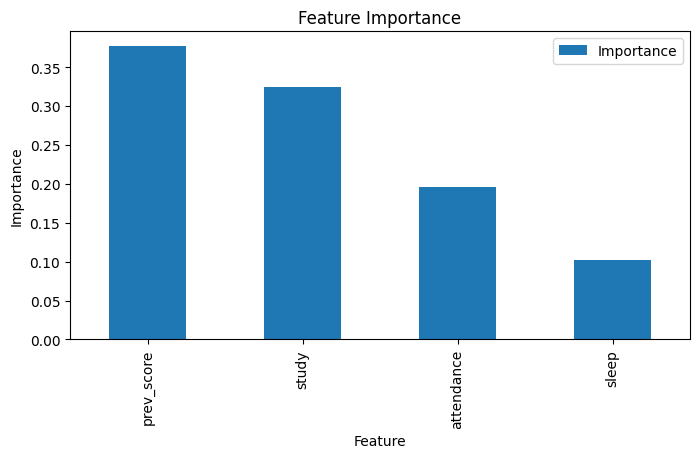

In [ ]:
import matplotlib.pyplot as plt

importance_df.plot(
    x = 'Feature',
    y = 'Importance',
    kind = 'bar',
    figsize = (8, 4)
)

plt.title('Feature Importance')
plt.ylabel('Importance')
plt.show()

In [ ]:
importance_df.columns

Index(['Feature', 'Importance'], dtype='object')

✍️ **Відповідь словами:**
> Найбільше на складання іспиту впливає ___.
Найважливіша ознака: prev_score-бал за минулий іспит = 0.377

### Крок B6. Передбач для нового студента
Студент: навчання 15 год, відвідуваність 85%, минулий бал 70, сон 7.5.
Виведи і рішення (`predict`), і **ймовірність** скласти (`predict_proba`).

*Підказка:* `predict_proba(...)[0, 1]` — це ймовірність класу «склав».

In [ ]:
# TODO: створи new_student, виведи рішення та ймовірність
# Створюємо нового студента
# Назви колонок мають повністю збігатися з Xs.columns
new_student = pd.DataFrame([{
    'study': 15,
    'attendance': 85,
    'prev_score': 70,
    'sleep': 7.5
}])

# Робимо прогноз класу
# 1 = склав
# 0 = не склав
prediction = tree.predict(new_student)

# Рахуємо ймовірність скласти іспит
# predict_proba()[0, 1] означає:
# 0-й студент, клас 1 = "склав"
probability = tree.predict_proba(new_student)[0, 1]

print("Прогноз:", prediction[0])
print("Ймовірність скласти:", round(probability, 3))


Прогноз: 1
Ймовірність скласти: 0.881


Модель передбачила клас 1, тобто студент складе іспит.

Ймовірність скласти іспит дорівнює 0.881,
тобто приблизно 88.1%.

Отже, за характеристиками:
навчання 15 годин, відвідуваність 85%,
минулий бал 70 і сон 7.5 годин,
модель вважає, що студент з високою ймовірністю складе іспит.

---
# ⭐ Бонус (необов'язково, але корисно)

1. **Перевір на перенавчання.** Для дерева зі Задачі B порахуй accuracy окремо на `Xs_train` і на `Xs_test`. Великий розрив = зубріння. Потім спробуй `max_depth=10` — розрив зросте?
2. **Сильніша модель.** Навчи `RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)` на тих самих даних і порівняй accuracy з деревом.
3. **Прибери ознаку.** У Задачі A прибери `experience` з `X`, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

1.Перевір на перенавчання. Для дерева зі Задачі B порахуй accuracy окремо на Xs_train і на Xs_test. Великий розрив = зубріння. Потім спробуй max_depth=10 — розрив зросте?

In [ ]:
# Місце для бонусних експериментів# Прогноз для train
train_pred = tree.predict(Xs_train)

# Прогноз для test
test_pred = tree.predict(Xs_test)

# Accuracy для train
train_acc = accuracy_score(ys_train, train_pred)

# Accuracy для test
test_acc = accuracy_score(ys_test, test_pred)

print("Train accuracy =", round(train_acc, 3))
print("Test accuracy =", round(test_acc, 3))

Train accuracy = 0.792
Test accuracy = 0.756


In [ ]:
tree2 = DecisionTreeClassifier(
    max_depth = 10,
    random_state = RANDOM_STATE
)

tree2.fit(Xs_train, ys_train)

train_acc2 = accuracy_score(
    ys_train,
    tree2.predict(Xs_train)
)

test_acc2 = accuracy_score(
    ys_test,
    tree2.predict(Xs_test)
)

print("Train accuracy =", round(train_acc2, 3))
print("Test accuracy =", round(test_acc2, 3))

Train accuracy = 0.97
Test accuracy = 0.719


Так, після збільшення max_depth до 10 розрив між train і test значно зріс.

Це означає, що модель почала перенавчатися.
Оптимальнішим для даного набору даних є дерево з max_depth = 4.

2.Сильніша модель. Навчи RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE) на тих самих даних і порівняй accuracy з деревом.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = RANDOM_STATE
)

rf.fit(Xs_train, ys_train)

rf_pred = rf.predict(Xs_test)

rf_acc = accuracy_score(
    ys_test,
    rf_pred
)

print("Random Forest accuracy =", round(rf_acc, 3))
print("Decision Tree accuracy =", round(acc, 3))

Random Forest accuracy = 0.769
Decision Tree accuracy = 0.756


Random Forest показав Accuracy = 0.769,
що трохи вище за Accuracy дерева рішень (0.756).

Це означає, що ансамбль із багатьох дерев
працює трохи краще за одне дерево.

Для цього набору даних Random Forest
виявився найточнішою моделлю.

3.Прибери ознаку. У Задачі A прибери experience з X, перенавчи й подивись, як впаде R². Який висновок про важливість стажу?

In [ ]:
# Видаляємо experience

X_no_exp = X.drop(
    columns = ['experience']
)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_no_exp,
    y,
    test_size = 0.2,
    random_state = 42
)

model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

r2 = r2_score(y_test, pred)

print("R² =", round(r2, 3))

R² = 0.767


Після видалення ознаки experience значення R² помітно зменшилося до 0.767.

Це означає, що стаж роботи є важливою ознакою для прогнозування зарплати.

Без інформації про стаж модель гірше пояснює зміну зарплати та робить менш точні прогнози.

---
# 🧠 Питання на розуміння (без коду)

Дай собі відповідь словами (правильні — у блокноті з розв'язками):
1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?
2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?
3. Що означає R² = 0.85 простими словами?
4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?
5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?

> 🎯 Якщо впорався із задачами A і B без підглядання — ти впевнено володієш базовим циклом ML. Вітаю!

1. Чому ми оцінюємо модель на `X_test`, а не на `X_train`?

Модель оцінюють на X_test, а не на X_train,
тому що X_test містить нові дані,
яких модель не бачила під час навчання.

Це дозволяє оцінити,
наскільки добре модель працює на реальних даних.

2. Задача «передбачити кількість проданих квитків» — це регресія чи класифікація? А «спам / не спам»?

Передбачення кількості проданих квитків — це задача регресії,
оскільки потрібно передбачити числове значення.

Задача "спам / не спам" — це класифікація,
оскільки потрібно вибрати один із двох класів.

3. Що означає R² = 0.85 простими словами?

R² = 0.85 означає,
що модель пояснює приблизно 85% змін цільової змінної.

Отже, модель досить добре описує залежність між ознаками та результатом.

4. Чому accuracy може бути оманливою, якщо лише 5% студентів провалюють іспит?

Accuracy може бути оманливою,
якщо класи дуже незбалансовані.

Наприклад, якщо лише 5% студентів провалюють іспит,
модель може завжди прогнозувати "склав"
і отримати Accuracy близько 95%,
але фактично не знаходити тих,
хто не склав іспит.

5. Коефіцієнт `english = +1500`. Як прочитати це вголос для керівника?

За інших рівних умов, кожен додатковий бал рівня володіння англійською мовою (за шкалою від 1 до 5) пов'язаний зі збільшенням заробітної плати приблизно на 1500 грн.